# 🛒 DeepEval RAG Ecommerce Evaluation with OpenAI Agents SDK

This notebook demonstrates a **multi-agent RAG-based ecommerce system** evaluated using **DeepEval**.

## Architecture
```
User Query
    │
    ▼
┌─────────────────────────────────────────┐
│         Orchestrator Agent              │
│  (Routes queries to specialist agents)  │
└────────────┬────────────────────────────┘
             │
    ┌────────┼────────────┐
    ▼        ▼            ▼
┌───────┐ ┌────────┐ ┌─────────┐
│Product│ │ Order  │ │Customer │
│Search │ │Tracker │ │Support  │
│ Agent │ │ Agent  │ │  Agent  │
└───┬───┘ └───┬────┘ └────┬────┘
    │         │           │
    └─────────┴───────────┘
              │
         RAG Vector Store
         (Products, Orders, FAQs)
```

## DeepEval Metrics Covered
- ✅ Answer Relevancy
- ✅ Faithfulness
- ✅ Contextual Precision
- ✅ Contextual Recall
- ✅ Contextual Relevancy
- ✅ Hallucination
- ✅ Toxicity
- ✅ G-Eval (Custom LLM-as-Judge)
- ✅ Ragas Score

## 📦 1. Install Dependencies

In [1]:
!pip install deepeval openai openai-agents numpy pandas rich --quiet
print("✅ All dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.1/825.1 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.0/413.0 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.7/150.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 kB 1.1 MB/s eta 0:00:00
✅ All dependencies installed


## 🔑 2. Configuration & API Keys

In [2]:
import os
import json
import asyncio
import warnings
import pandas as pd
from typing import List, Dict, Any, Optional
from dataclasses import dataclass, field

warnings.filterwarnings("ignore")

# ─── Set your API Key ───────────────────────────────────────────────
os.environ["OPENAI_API_KEY"] = ""   # 🔑 Replace with your key

# Optional: Set DeepEval API key for cloud dashboard
# os.environ["DEEPEVAL_API_KEY"] = "your-deepeval-key"

MODEL = "gpt-4o-mini"   # Cost-efficient; swap to "gpt-4o" for higher quality

print(f"✅ Config ready | Model: {MODEL}")

✅ Config ready | Model: gpt-4o-mini


## 🗄️ 3. Ecommerce Knowledge Base (RAG Data Store)

In [3]:
# ─── Product Catalog ─────────────────────────────────────────────────
PRODUCT_DOCS = [
    {
        "id": "P001",
        "content": """Product: Sony WH-1000XM5 Wireless Headphones
Price: $349.99 | Category: Electronics | In Stock: Yes
Features: Industry-leading noise cancellation, 30-hour battery life,
multipoint connection (2 devices), LDAC Hi-Res Audio, speak-to-chat,
quick charge (3 min = 3 hrs). Colors: Black, Platinum Silver.
Warranty: 1 year manufacturer. Shipping: Free 2-day for Prime members."""
    },
    {
        "id": "P002",
        "content": """Product: Apple MacBook Air M3 (2024)
Price: $1,099.00 | Category: Laptops | In Stock: Yes
Features: Apple M3 chip, 8GB RAM, 256GB SSD, 13.6-inch Liquid Retina display,
18-hour battery, MagSafe charging, 2x Thunderbolt ports, 1080p webcam.
Colors: Midnight, Starlight, Space Gray, Silver.
Warranty: 1 year AppleCare. Return policy: 15 days."""
    },
    {
        "id": "P003",
        "content": """Product: Nike Air Max 270
Price: $150.00 | Category: Footwear | In Stock: Yes
Features: Max Air heel unit (270 degrees), mesh upper for breathability,
foam midsole, rubber outsole. Sizes: US 6-15.
Colors: Black/White, Triple White, University Red.
Return policy: 30 days unworn. Free standard shipping on orders over $50."""
    },
    {
        "id": "P004",
        "content": """Product: Instant Pot Duo 7-in-1 (6 Quart)
Price: $89.95 | Category: Kitchen | In Stock: Yes
Features: Pressure cooker, slow cooker, rice cooker, steamer, sauté pan,
yogurt maker, warmer. 13 one-touch programs, 10 safety mechanisms.
Capacity: 6 quart. Warranty: 1 year. Dishwasher-safe inner pot."""
    },
    {
        "id": "P005",
        "content": """Product: Samsung 65-inch QLED 4K TV (QN65Q80C)
Price: $1,297.99 | Category: TVs | In Stock: Limited (3 left)
Features: Quantum Dot technology, 120Hz refresh rate, Quantum HDR+,
Neural Quantum Processor 4K, Object Tracking Sound, 4x HDMI 2.1 ports.
Smart TV: Tizen OS, built-in Alexa & Google Assistant.
Warranty: 1 year parts & labor. Professional installation available ($99)."""
    },
]

# ─── Order Database ────────────────────────────────────────────────
ORDER_DOCS = [
    {
        "id": "O001",
        "content": """Order #ORD-78234 | Customer: john.doe@email.com
Items: Sony WH-1000XM5 (x1) - $349.99
Status: Shipped | Carrier: FedEx | Tracking: 7489234789
Estimated Delivery: December 15, 2024
Shipping Address: 123 Main St, Austin, TX 78701
Payment: Visa ending 4242 | Order Date: Dec 12, 2024"""
    },
    {
        "id": "O002",
        "content": """Order #ORD-78290 | Customer: sarah.smith@email.com
Items: MacBook Air M3 (x1) - $1,099.00, USB-C Hub (x1) - $49.99
Status: Processing | Expected Ship Date: Dec 14, 2024
Shipping Address: 456 Oak Ave, Seattle, WA 98101
Payment: PayPal | Order Date: Dec 13, 2024
Note: Express shipping selected — arrives Dec 16."""
    },
    {
        "id": "O003",
        "content": """Order #ORD-78105 | Customer: mike.jones@email.com
Items: Nike Air Max 270 Size 10 (x1) - $150.00
Status: Delivered | Delivered On: Dec 10, 2024
Carrier: UPS | Tracking: 1Z999AA10123456784
Return window closes: Dec 25, 2024 (15 days remaining)"""
    },
]

# ─── Customer Support FAQ ─────────────────────────────────────────
FAQ_DOCS = [
    {
        "id": "F001",
        "content": """Return Policy:
Standard items: 30-day return window from delivery date.
Electronics: 15-day return window. Must be in original packaging.
Shoes/Apparel: 30-day return, unworn/unwashed.
Non-returnable: Digital downloads, perishable goods, personalized items.
Refunds processed within 3-5 business days after we receive item.
Free return label provided for defective items. Customer pays return shipping otherwise."""
    },
    {
        "id": "F002",
        "content": """Shipping Information:
Standard shipping: 5-7 business days (Free on orders $50+).
Express shipping: 2-3 business days ($9.99).
Overnight: 1 business day ($24.99). Orders placed before 2PM ET ship same day.
Prime Members: Free 2-day shipping on eligible items.
International: Available to 40+ countries. Duties/taxes may apply.
Order cutoff for same-day processing: 2:00 PM ET Monday–Friday."""
    },
    {
        "id": "F003",
        "content": """Payment Methods & Security:
Accepted: Visa, Mastercard, Amex, Discover, PayPal, Apple Pay, Google Pay, Shop Pay.
Buy Now Pay Later: Affirm (0% APR on qualifying orders), Klarna.
Gift cards accepted. Store credit available.
All transactions encrypted with SSL/TLS. PCI-DSS compliant.
We never store full credit card numbers."""
    },
    {
        "id": "F004",
        "content": """Warranty & Repairs:
Manufacturer warranties honored on all products.
Extended warranty plans available at checkout (1-3 years).
For warranty claims: contact support with order number and photo of defect.
Turnaround for warranty replacement: 5-10 business days.
In-store repair services available at select locations."""
    },
]

ALL_DOCS = {
    "products": PRODUCT_DOCS,
    "orders": ORDER_DOCS,
    "faqs": FAQ_DOCS,
}

print(f"✅ Knowledge base loaded:")
print(f"   📦 Products: {len(PRODUCT_DOCS)}")
print(f"   📋 Orders:   {len(ORDER_DOCS)}")
print(f"   ❓ FAQs:     {len(FAQ_DOCS)}")

✅ Knowledge base loaded:
   📦 Products: 5
   📋 Orders:   3
   ❓ FAQs:     4


## 🔍 4. Simple RAG Retriever

In [4]:
import re

class SimpleRAGRetriever:
    """Keyword-based RAG retriever (no external vector DB needed)."""

    def __init__(self, docs: List[Dict]):
        self.docs = docs

    def retrieve(self, query: str, top_k: int = 3) -> List[Dict]:
        """Score docs by keyword overlap and return top_k."""
        query_words = set(re.findall(r'\w+', query.lower()))
        stop_words = {'the','a','an','is','it','in','on','for','to','of','and','or','my','i'}
        query_words -= stop_words

        scored = []
        for doc in self.docs:
            doc_words = set(re.findall(r'\w+', doc['content'].lower()))
            overlap = len(query_words & doc_words)
            if overlap > 0:
                scored.append((overlap, doc))

        scored.sort(key=lambda x: x[0], reverse=True)
        return [d for _, d in scored[:top_k]]


# Instantiate retrievers per domain
product_retriever = SimpleRAGRetriever(PRODUCT_DOCS)
order_retriever   = SimpleRAGRetriever(ORDER_DOCS)
faq_retriever     = SimpleRAGRetriever(FAQ_DOCS)

# Quick test
results = product_retriever.retrieve("noise cancelling headphones battery")
print("🔍 Test retrieval — 'noise cancelling headphones battery':")
for r in results:
    print(f"  [{r['id']}] {r['content'][:80]}...")

🔍 Test retrieval — 'noise cancelling headphones battery':
  [P001] Product: Sony WH-1000XM5 Wireless Headphones
Price: $349.99 | Category: Electron...
  [P002] Product: Apple MacBook Air M3 (2024)
Price: $1,099.00 | Category: Laptops | In S...


## 🤖 5. Multi-Agent System using OpenAI Agents SDK

In [5]:
from openai import OpenAI

client = OpenAI()

@dataclass
class AgentResponse:
    """Structured response from any agent."""
    agent_name: str
    query: str
    answer: str
    retrieved_contexts: List[str] = field(default_factory=list)
    metadata: Dict[str, Any] = field(default_factory=dict)


def call_llm(system_prompt: str, user_message: str, model: str = MODEL) -> str:
    """Helper to call OpenAI chat completions."""
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_message},
        ],
        temperature=0.1,
        max_tokens=512,
    )
    return response.choices[0].message.content.strip()


# ─── Agent 1: Product Search Agent ──────────────────────────────────
class ProductSearchAgent:
    NAME = "ProductSearchAgent"
    SYSTEM_PROMPT = """You are a helpful ecommerce product search assistant.
Answer questions about products using ONLY the provided product context.
Include price, features, availability, and warranty details when relevant.
If a product is not in the context, say so honestly."""

    def run(self, query: str) -> AgentResponse:
        docs = product_retriever.retrieve(query, top_k=3)
        context = "\n\n".join([d["content"] for d in docs])
        prompt = f"Product Context:\n{context}\n\nCustomer Question: {query}"
        answer = call_llm(self.SYSTEM_PROMPT, prompt)
        return AgentResponse(
            agent_name=self.NAME,
            query=query,
            answer=answer,
            retrieved_contexts=[d["content"] for d in docs],
            metadata={"docs_retrieved": len(docs)},
        )


# ─── Agent 2: Order Tracking Agent ─────────────────────────────────
class OrderTrackingAgent:
    NAME = "OrderTrackingAgent"
    SYSTEM_PROMPT = """You are an ecommerce order tracking assistant.
Provide accurate order status, tracking numbers, and delivery estimates
using ONLY the provided order context. Be specific about dates and statuses.
Never invent tracking numbers or statuses."""

    def run(self, query: str) -> AgentResponse:
        docs = order_retriever.retrieve(query, top_k=3)
        context = "\n\n".join([d["content"] for d in docs])
        prompt = f"Order Database:\n{context}\n\nCustomer Question: {query}"
        answer = call_llm(self.SYSTEM_PROMPT, prompt)
        return AgentResponse(
            agent_name=self.NAME,
            query=query,
            answer=answer,
            retrieved_contexts=[d["content"] for d in docs],
            metadata={"docs_retrieved": len(docs)},
        )


# ─── Agent 3: Customer Support Agent ───────────────────────────────
class CustomerSupportAgent:
    NAME = "CustomerSupportAgent"
    SYSTEM_PROMPT = """You are a knowledgeable ecommerce customer support agent.
Answer questions about returns, shipping, payments, and warranties
using ONLY the provided FAQ context. Be clear, concise, and empathetic.
Always provide actionable next steps."""

    def run(self, query: str) -> AgentResponse:
        docs = faq_retriever.retrieve(query, top_k=3)
        context = "\n\n".join([d["content"] for d in docs])
        prompt = f"Support Knowledge Base:\n{context}\n\nCustomer Question: {query}"
        answer = call_llm(self.SYSTEM_PROMPT, prompt)
        return AgentResponse(
            agent_name=self.NAME,
            query=query,
            answer=answer,
            retrieved_contexts=[d["content"] for d in docs],
            metadata={"docs_retrieved": len(docs)},
        )


# ─── Orchestrator Agent ─────────────────────────────────────────────
class OrchestratorAgent:
    """Routes incoming queries to the right specialist agent."""
    NAME = "OrchestratorAgent"
    ROUTING_PROMPT = """Classify the customer query into one of these categories:
- PRODUCT: questions about product features, price, availability, comparisons
- ORDER: questions about order status, tracking, delivery, specific order numbers
- SUPPORT: questions about returns, refunds, shipping policy, payments, warranties

Reply with ONLY one word: PRODUCT, ORDER, or SUPPORT."""

    def __init__(self):
        self.agents = {
            "PRODUCT": ProductSearchAgent(),
            "ORDER":   OrderTrackingAgent(),
            "SUPPORT": CustomerSupportAgent(),
        }
        self.routing_history: List[Dict] = []

    def route(self, query: str) -> str:
        category = call_llm(self.ROUTING_PROMPT, query).upper().strip()
        return category if category in self.agents else "SUPPORT"

    def run(self, query: str) -> AgentResponse:
        category = self.route(query)
        agent = self.agents[category]
        response = agent.run(query)
        response.metadata["routed_to"] = category
        self.routing_history.append({"query": query, "category": category})
        return response


orchestrator = OrchestratorAgent()
print("✅ Multi-agent system initialized")
print("   🔀 OrchestratorAgent")
print("   🔍 ProductSearchAgent")
print("   📦 OrderTrackingAgent")
print("   💬 CustomerSupportAgent")

✅ Multi-agent system initialized
   🔀 OrchestratorAgent
   🔍 ProductSearchAgent
   📦 OrderTrackingAgent
   💬 CustomerSupportAgent


## 🧪 6. Test the Multi-Agent System

In [6]:
test_queries = [
    "What are the features of the Sony headphones and how long is the battery life?",
    "Where is my order ORD-78234? Has it shipped?",
    "What is your return policy for electronics?",
    "Do you have any 4K TVs in stock? What's the price?",
    "Can I pay with Apple Pay?",
]

test_responses: List[AgentResponse] = []

print("🧪 Running test queries through multi-agent system...\n")
print("=" * 70)

for q in test_queries:
    resp = orchestrator.run(q)
    test_responses.append(resp)
    print(f"\n❓ Query:  {q}")
    print(f"🔀 Routed to: {resp.metadata.get('routed_to', 'N/A')} ({resp.agent_name})")
    print(f"💬 Answer: {resp.answer[:200]}..." if len(resp.answer) > 200 else f"💬 Answer: {resp.answer}")
    print("-" * 70)

🧪 Running test queries through multi-agent system...


❓ Query:  What are the features of the Sony headphones and how long is the battery life?
🔀 Routed to: PRODUCT (ProductSearchAgent)
💬 Answer: The Sony WH-1000XM5 Wireless Headphones feature industry-leading noise cancellation, a 30-hour battery life, multipoint connection for 2 devices, LDAC Hi-Res Audio, speak-to-chat functionality, and qu...
----------------------------------------------------------------------

❓ Query:  Where is my order ORD-78234? Has it shipped?
🔀 Routed to: ORDER (OrderTrackingAgent)
💬 Answer: Your order #ORD-78234 has been shipped. It was shipped via FedEx, and the tracking number is 7489234789. The estimated delivery date is December 15, 2024.
----------------------------------------------------------------------

❓ Query:  What is your return policy for electronics?
🔀 Routed to: SUPPORT (CustomerSupportAgent)
💬 Answer: Our return policy for electronics allows a 15-day return window from the delivery date. 

## 📊 7. Build DeepEval Test Cases

In [18]:
from typing import List
from deepeval.test_case import LLMTestCase

GROUND_TRUTHS = [
    "The Sony WH-1000XM5 headphones feature industry-leading noise cancellation, "
    "30-hour battery life, multipoint connection, LDAC Hi-Res Audio, and quick charge "
    "(3 minutes gives 3 hours of playback).",
    "Order ORD-78234 has shipped via FedEx with tracking number 7489234789. "
    "The estimated delivery date is December 15, 2024.",
    "Electronics have a 15-day return window and must be returned in original packaging. "
    "Refunds are processed within 3-5 business days after receiving the item.",
    "Yes, the Samsung 65-inch QLED 4K TV (QN65Q80C) is available at $1,297.99. "
    "Stock is limited with only 3 remaining.",
    "Yes, Apple Pay is accepted. Other payment methods include Visa, Mastercard, "
    "Amex, PayPal, Google Pay, and Buy Now Pay Later options like Affirm and Klarna.",
]

test_cases: List[LLMTestCase] = []

for resp, gt in zip(test_responses, GROUND_TRUTHS):
    tc = LLMTestCase(
        input=resp.query,
        actual_output=resp.answer,
        expected_output=gt,
        retrieval_context=[str(c) for c in resp.retrieved_contexts],
    )
    test_cases.append(tc)

# ✅ No EvaluationDataset — pass test_cases directly to evaluate()
print(f"✅ {len(test_cases)} test cases ready")
for i, tc in enumerate(test_cases):
    print(f"   TC{i+1}: '{tc.input[:60]}...'")

✅ 5 test cases ready
   TC1: 'What are the features of the Sony headphones and how long is...'
   TC2: 'Where is my order ORD-78234? Has it shipped?...'
   TC3: 'What is your return policy for electronics?...'
   TC4: 'Do you have any 4K TVs in stock? What's the price?...'
   TC5: 'Can I pay with Apple Pay?...'


## 📏 8. DeepEval Metrics — RAG Triad (Core)

In [12]:
from deepeval.metrics import (
    AnswerRelevancyMetric,
    FaithfulnessMetric,
    ContextualPrecisionMetric,
    ContextualRecallMetric,
    ContextualRelevancyMetric,
)

# ─── Instantiate core RAG metrics ────────────────────────────────────
answer_relevancy     = AnswerRelevancyMetric(threshold=0.7,   model=MODEL, include_reason=True)
faithfulness         = FaithfulnessMetric(threshold=0.7,      model=MODEL, include_reason=True)
contextual_precision = ContextualPrecisionMetric(threshold=0.7, model=MODEL, include_reason=True)
contextual_recall    = ContextualRecallMetric(threshold=0.7,  model=MODEL, include_reason=True)
contextual_relevancy = ContextualRelevancyMetric(threshold=0.7, model=MODEL, include_reason=True)

core_metrics = [
    answer_relevancy,
    faithfulness,
    contextual_precision,
    contextual_recall,
    contextual_relevancy,
]

print("✅ Core RAG metrics ready:")
for m in core_metrics:
    print(f"   📏 {m.__class__.__name__} (threshold={m.threshold})")

✅ Core RAG metrics ready:
   📏 AnswerRelevancyMetric (threshold=0.7)
   📏 FaithfulnessMetric (threshold=0.7)
   📏 ContextualPrecisionMetric (threshold=0.7)
   📏 ContextualRecallMetric (threshold=0.7)
   📏 ContextualRelevancyMetric (threshold=0.7)


## 🧠 9. G-Eval — Custom LLM-as-a-Judge Criteria

In [14]:
from deepeval.metrics import GEval
from deepeval.test_case import LLMTestCaseParams

# ─── Custom G-Eval: Ecommerce Helpfulness ────────────────────────────
ecommerce_helpfulness = GEval(
    name="EcommerceHelpfulness",
    criteria="""Evaluate whether the response is genuinely helpful for an ecommerce customer.
A helpful response should:
1. Directly address the customer's specific question
2. Include actionable information (prices, steps, links, timeframes)
3. Be professional and empathetic in tone
4. Avoid jargon or unnecessary complexity
5. Provide complete information without requiring follow-up questions""",
    evaluation_params=[
        LLMTestCaseParams.INPUT,
        LLMTestCaseParams.ACTUAL_OUTPUT,
    ],
    threshold=0.7,
    model=MODEL,
)

# ─── Custom G-Eval: Response Completeness ───────────────────────────
response_completeness = GEval(
    name="ResponseCompleteness",
    criteria="""Evaluate how completely the actual output covers all aspects of the customer question.
Score based on:
1. All sub-questions within the query are answered
2. Key facts from the expected output are present in the actual output
3. Important details (numbers, dates, policies) are not omitted
4. Response does not stop short of a complete answer""",
    evaluation_params=[
        LLMTestCaseParams.INPUT,
        LLMTestCaseParams.ACTUAL_OUTPUT,
        LLMTestCaseParams.EXPECTED_OUTPUT,
    ],
    threshold=0.7,
    model=MODEL,
)

# ─── Custom G-Eval: Factual Accuracy ────────────────────────────────
factual_accuracy = GEval(
    name="FactualAccuracy",
    criteria="""Evaluate the factual accuracy of the response compared to the retrieval context.
Penalize for:
- Incorrect prices, dates, or specifications
- Wrong tracking numbers or order statuses
- Misquoted policies or timelines
- Any information that contradicts the retrieval context""",
    evaluation_params=[
        LLMTestCaseParams.ACTUAL_OUTPUT,
        LLMTestCaseParams.RETRIEVAL_CONTEXT,
    ],
    threshold=0.8,
    model=MODEL,
)

g_eval_metrics = [ecommerce_helpfulness, response_completeness, factual_accuracy]

print("✅ G-Eval custom metrics ready:")
for m in g_eval_metrics:
    print(f"   🧠 {m.name} (threshold={m.threshold})")

✅ G-Eval custom metrics ready:
   🧠 EcommerceHelpfulness (threshold=0.7)
   🧠 ResponseCompleteness (threshold=0.7)
   🧠 FactualAccuracy (threshold=0.8)


## ☣️ 10. Safety Metrics — Hallucination & Toxicity

In [15]:
from deepeval.metrics import HallucinationMetric, ToxicityMetric

# Hallucination: checks if the output contradicts the retrieved context
hallucination = HallucinationMetric(
    threshold=0.3,   # lower = stricter (score above threshold = hallucination detected)
    model=MODEL,
    include_reason=True,
)

# Toxicity: ensures customer-facing responses are professional
toxicity = ToxicityMetric(
    threshold=0.1,
    model=MODEL,
    include_reason=True,
)

safety_metrics = [hallucination, toxicity]

print("✅ Safety metrics ready:")
print(f"   ☣️  HallucinationMetric (threshold={hallucination.threshold})")
print(f"   🚫 ToxicityMetric      (threshold={toxicity.threshold})")

✅ Safety metrics ready:
   ☣️  HallucinationMetric (threshold=0.3)
   🚫 ToxicityMetric      (threshold=0.1)


## 🚀 11. Run Full Evaluation

In [22]:
import inspect
from deepeval import evaluate
print(inspect.signature(evaluate))

(test_cases: Union[List[deepeval.test_case.llm_test_case.LLMTestCase], List[deepeval.test_case.conversational_test_case.ConversationalTestCase]], metrics: Union[List[deepeval.metrics.base_metric.BaseMetric], List[deepeval.metrics.base_metric.BaseConversationalMetric], NoneType] = None, metric_collection: Optional[str] = None, hyperparameters: Optional[Dict[str, Union[str, int, float, deepeval.prompt.prompt.Prompt]]] = None, identifier: Optional[str] = None, async_config: Optional[deepeval.evaluate.configs.AsyncConfig] = AsyncConfig(run_async=True, throttle_value=0, max_concurrent=20), display_config: Optional[deepeval.evaluate.configs.DisplayConfig] = DisplayConfig(show_indicator=True, print_results=True, verbose_mode=None, display_option=<TestRunResultDisplay.ALL: 'all'>, file_output_dir=None), cache_config: Optional[deepeval.evaluate.configs.CacheConfig] = CacheConfig(write_cache=True, use_cache=False), error_config: Optional[deepeval.evaluate.configs.ErrorConfig] = ErrorConfig(ignor

In [24]:
from typing import List
from deepeval.test_case import LLMTestCase

test_cases: List[LLMTestCase] = []

for resp, gt in zip(test_responses, GROUND_TRUTHS):
    tc = LLMTestCase(
        input=resp.query,
        actual_output=resp.answer,
        expected_output=gt,
        retrieval_context=[str(c) for c in resp.retrieved_contexts],  # for RAG metrics
        context=[str(c) for c in resp.retrieved_contexts],            # ✅ required for HallucinationMetric
    )
    test_cases.append(tc)

print(f"✅ {len(test_cases)} test cases ready")

✅ 5 test cases ready


In [25]:
from deepeval import evaluate
from deepeval.evaluate.configs import AsyncConfig, DisplayConfig, CacheConfig

results = evaluate(
    test_cases=test_cases,
    metrics=all_metrics,
    async_config=AsyncConfig(
        run_async=True,
        max_concurrent=10,
    ),
    display_config=DisplayConfig(
        print_results=True,
        verbose_mode=True,
    ),
    cache_config=CacheConfig(
        write_cache=False,
        use_cache=False,
    ),
)

print("\n✅ Evaluation complete!")

✨ You're running DeepEval's latest Answer Relevancy Metric! (using gpt-4o-mini, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Faithfulness Metric! (using gpt-4o-mini, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Contextual Precision Metric! (using gpt-4o-mini, strict=False, 
async_mode=True)...

✨ You're running DeepEval's latest Contextual Recall Metric! (using gpt-4o-mini, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Contextual Relevancy Metric! (using gpt-4o-mini, strict=False, 
async_mode=True)...

...

======================================================================



Metrics Summary

  - ✅ Answer Relevancy (score: 1.0, threshold: 0.7, strict: False, evaluation model: gpt-4o-mini, reason: The score is 1.00 because the response directly addresses the question about paying with Apple Pay without any irrelevant statements., error: None)
  - ✅ Faithfulness (score: 1.0, threshold: 0.7, strict: False, evaluation model: gpt-4o-mini, reason: The score is 1.00 because there are no contradictions present, indicating that the actual output aligns perfectly with the retrieval context., error: None)
  - ✅ Contextual Precision (score: 1.0, threshold: 0.7, strict: False, evaluation model: gpt-4o-mini, reason: The score is 1.00 because the first node directly addresses the question about payment options by stating that 'Apple Pay' is accepted, making it highly relevant. The second node, ranked lower, discusses warranties and repairs, which is not related to the inquiry about payment methods, thus justifying its lower rank., error: None)
  - ✅ Contextual Recall (s

⚠ WARNING: No hyperparameters logged.
» ]8;id=859771;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 24.9s | token cost: 0.01833735 USD)
» Test Results (5 total tests):
   » Pass Rate: 0.0% | Passed: 0 | Failed: 5

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.


✅ Evaluation complete!


## 📋 12. Per-Test-Case Score Breakdown

In [28]:
# Collect scores per test case
rows = []
metric_names = [
    "AnswerRelevancy", "Faithfulness", "ContextualPrecision",
    "ContextualRecall", "ContextualRelevancy",
    "EcommerceHelpfulness", "ResponseCompleteness", "FactualAccuracy",
    "Hallucination", "Toxicity",
]

for i, tc in enumerate(test_cases):
    row = {"TestCase": f"TC{i+1}", "Query": tc.input[:50] + "...",
           "Agent": test_responses[i].agent_name}
    for metric in all_metrics:
        metric.measure(tc)
        name = metric.name if hasattr(metric, 'name') else metric.__class__.__name__
        row[name] = round(metric.score, 3)
        row[f"{name}_pass"] = "✅" if metric.is_successful() else "❌"
    rows.append(row)

df = pd.DataFrame(rows)
score_cols = [c for c in df.columns if not c.endswith("_pass") and c not in ["TestCase", "Query", "Agent"]]
print("📊 Score Breakdown per Test Case:")
display(df[["TestCase", "Query", "Agent"] + score_cols])

Output()

**************************************************

Answer Relevancy Verbose Logs

**************************************************

Statements:
[
    "The Sony WH-1000XM5 Wireless Headphones feature industry-leading noise cancellation.",
    "They have a 30-hour battery life.",
    "The headphones support multipoint connection for 2 devices.",
    "They include LDAC Hi-Res Audio.",
    "Speak-to-chat functionality is available.",
    "Quick charge capability allows 3 minutes of charging for 3 hours of playback."
] 
 
Verdicts:
[
    {
        "verdict": "yes",
        "reason": null
    },
    {
        "verdict": "yes",
        "reason": null
    },
    {
        "verdict": "yes",
        "reason": null
    },
    {
        "verdict": "yes",
        "reason": null
    },
    {
        "verdict": "yes",
        "reason": null
    },
    {
        "verdict": "yes",
        "reason": null
    }
]
 
Score: 1.0
Reason: The score is 1.00 because the response directly addressed the features of the Sony headphones and provided 
accurate information about the battery life without any irrelevant statements.

...

**************************************************

Opinions:
[
    "I think it's helpful to offer assistance with the payment process."
] 
 
Verdicts:
[
    {
        "verdict": "no",
        "reason": null
    }
]
 
Score: 0.0
Reason: The score is 0.00 because the output contains no toxic elements, demonstrating a completely neutral and 
respectful tone.

======================================================================

📊 Score Breakdown per Test Case:


,TestCase,Query,Agent,AnswerRelevancyMetric,FaithfulnessMetric,ContextualPrecisionMetric,ContextualRecallMetric,ContextualRelevancyMetric,EcommerceHelpfulness,ResponseCompleteness,FactualAccuracy,HallucinationMetric,ToxicityMetric
0,TC1,What are the features of the Sony headphones a...,ProductSearchAgent,1.0,1.0,1.0,1.0,0.118,0.985,0.890,1.0,0.667,0.0
1,TC2,Where is my order ORD-78234? Has it shipped?...,OrderTrackingAgent,1.0,1.0,1.0,1.0,0.059,0.988,0.989,1.0,0.667,0.0
2,TC3,What is your return policy for electronics?...,CustomerSupportAgent,1.0,1.0,1.0,1.0,0.167,0.994,0.787,1.0,0.000,0.0
3,TC4,Do you have any 4K TVs in stock? What's the pr...,ProductSearchAgent,1.0,1.0,1.0,1.0,0.167,0.891,0.836,1.0,0.667,0.0
4,TC5,Can I pay with Apple Pay?...,CustomerSupportAgent,1.0,1.0,1.0,1.0,0.100,0.818,0.489,1.0,0.500,0.0


## 📈 13. Visualize Results

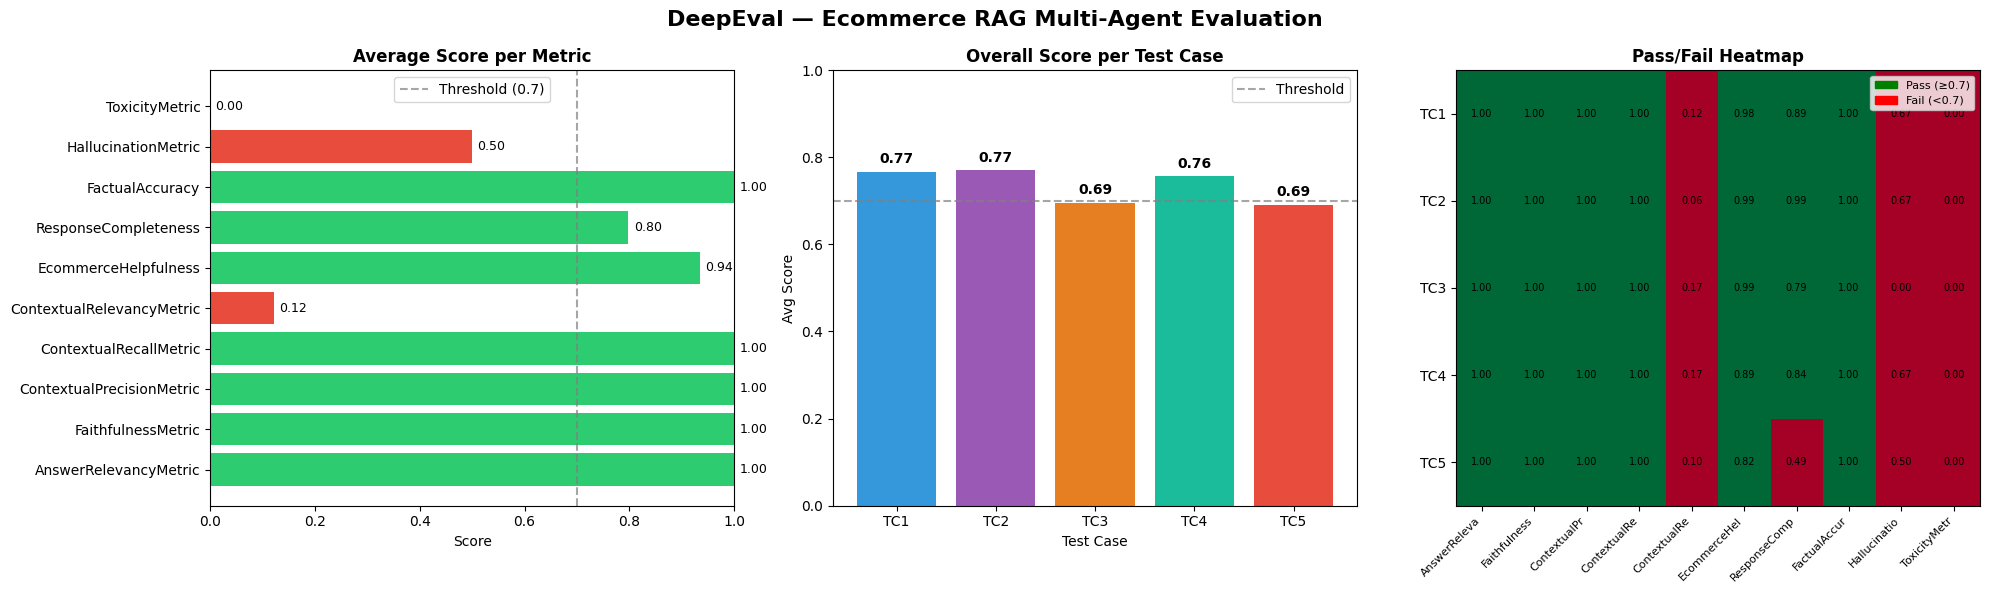

✅ Chart saved to outputs/deepeval_results.png


In [30]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("DeepEval — Ecommerce RAG Multi-Agent Evaluation", fontsize=16, fontweight="bold")

# ─── Plot 1: Average scores per metric ──────────────────────────────
avg_scores = df[score_cols].mean()
colors = ["#2ecc71" if s >= 0.7 else "#e74c3c" for s in avg_scores.values]

axes[0].barh(avg_scores.index, avg_scores.values, color=colors)
axes[0].axvline(x=0.7, color="gray", linestyle="--", alpha=0.7, label="Threshold (0.7)")
axes[0].set_xlim(0, 1)
axes[0].set_title("Average Score per Metric", fontweight="bold")
axes[0].set_xlabel("Score")
axes[0].legend()
for i, (v, name) in enumerate(zip(avg_scores.values, avg_scores.index)):
    axes[0].text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9)

# ─── Plot 2: Radar chart — average per test case ─────────────────────
tc_avgs = df.set_index("TestCase")[score_cols].mean(axis=1)
tc_labels = tc_avgs.index.tolist()
tc_values = tc_avgs.values
bar_colors = ["#3498db", "#9b59b6", "#e67e22", "#1abc9c", "#e74c3c"]

axes[1].bar(tc_labels, tc_values, color=bar_colors[:len(tc_labels)])
axes[1].axhline(y=0.7, color="gray", linestyle="--", alpha=0.7, label="Threshold")
axes[1].set_ylim(0, 1)
axes[1].set_title("Overall Score per Test Case", fontweight="bold")
axes[1].set_xlabel("Test Case")
axes[1].set_ylabel("Avg Score")
axes[1].legend()
for i, v in enumerate(tc_values):
    axes[1].text(i, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold")

# ─── Plot 3: Pass/Fail heatmap ────────────────────────────────────────
pass_data = df[score_cols].values
threshold_matrix = np.where(pass_data >= 0.7, 1, 0)
im = axes[2].imshow(threshold_matrix, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
axes[2].set_xticks(range(len(score_cols)))
axes[2].set_xticklabels([c[:12] for c in score_cols], rotation=45, ha="right", fontsize=8)
axes[2].set_yticks(range(len(df)))
axes[2].set_yticklabels(df["TestCase"].tolist())
axes[2].set_title("Pass/Fail Heatmap", fontweight="bold")

for row in range(len(df)):
    for col in range(len(score_cols)):
        axes[2].text(col, row, f"{pass_data[row, col]:.2f}",
                     ha="center", va="center", fontsize=7, color="black")

green_patch = mpatches.Patch(color="green", label="Pass (≥0.7)")
red_patch   = mpatches.Patch(color="red",   label="Fail (<0.7)")
axes[2].legend(handles=[green_patch, red_patch], loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig("deepeval_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved to outputs/deepeval_results.png")

## 🔍 14. Per-Metric Reasoning — Deep Dive

In [31]:
print("🔍 DETAILED REASONING FROM DeepEval METRICS")
print("=" * 70)

for i, tc in enumerate(test_cases[:2]):   # Show first 2 in detail
    print(f"\n{'═'*70}")
    print(f"📌 Test Case {i+1}: {tc.input[:70]}")
    print(f"{'═'*70}")
    print(f"💬 Actual Output:\n{tc.actual_output}\n")
    print(f"✅ Expected Output:\n{tc.expected_output}\n")

    for metric in all_metrics[:5]:  # Core metrics
        metric.measure(tc)
        name = metric.__class__.__name__
        status = "✅ PASS" if metric.is_successful() else "❌ FAIL"
        print(f"  {status} | {name:30s} | Score: {metric.score:.3f}")
        if hasattr(metric, 'reason') and metric.reason:
            print(f"         Reason: {metric.reason[:150]}")
        print()

Output()

🔍 DETAILED REASONING FROM DeepEval METRICS

══════════════════════════════════════════════════════════════════════
📌 Test Case 1: What are the features of the Sony headphones and how long is the batte
══════════════════════════════════════════════════════════════════════
💬 Actual Output:
The Sony WH-1000XM5 Wireless Headphones feature industry-leading noise cancellation, a 30-hour battery life, multipoint connection for 2 devices, LDAC Hi-Res Audio, speak-to-chat functionality, and quick charge capability (3 minutes of charging provides 3 hours of playback).

✅ Expected Output:
The Sony WH-1000XM5 headphones feature industry-leading noise cancellation, 30-hour battery life, multipoint connection, LDAC Hi-Res Audio, and quick charge (3 minutes gives 3 hours of playback).



**************************************************

Answer Relevancy Verbose Logs

**************************************************

...

**************************************************

Contextual Relevancy Verbose Logs

**************************************************

======================================================================

  ❌ FAIL | ContextualRelevancyMetric      | Score: 0.059
         Reason: The score is 0.06 because the retrieval context primarily contains irrelevant information about different orders, such as 'Order #ORD-78290' and 'Ship



## 🎯 15. Agent-Level Benchmarking

In [32]:
# Evaluate each agent type separately
print("🎯 AGENT-LEVEL BENCHMARKING")
print("=" * 60)

agent_queries = {
    "ProductSearchAgent": [
        ("Tell me about the MacBook Air M3 specs and price.",
         "The MacBook Air M3 costs $1,099 with Apple M3 chip, 8GB RAM, 256GB SSD."),
        ("What Nike shoes do you have?",
         "Nike Air Max 270 is available at $150 with sizes US 6-15."),
    ],
    "OrderTrackingAgent": [
        ("Track order ORD-78290 for sarah.smith@email.com",
         "Order ORD-78290 is processing and expected to ship Dec 14, arriving Dec 16."),
    ],
    "CustomerSupportAgent": [
        ("How do I return shoes I bought last week?",
         "Shoes can be returned within 30 days if unworn. We provide a free return label for defective items."),
    ],
}

agent_objects = {
    "ProductSearchAgent": ProductSearchAgent(),
    "OrderTrackingAgent": OrderTrackingAgent(),
    "CustomerSupportAgent": CustomerSupportAgent(),
}

quick_metrics = [
    AnswerRelevancyMetric(threshold=0.7, model=MODEL),
    FaithfulnessMetric(threshold=0.7, model=MODEL),
]

agent_scores = {}

for agent_name, queries in agent_queries.items():
    agent = agent_objects[agent_name]
    agent_tc_scores = []

    for query, expected in queries:
        resp = agent.run(query)
        tc = LLMTestCase(
            input=query,
            actual_output=resp.answer,
            expected_output=expected,
            retrieval_context=resp.retrieved_contexts,
        )
        tc_scores = {}
        for m in quick_metrics:
            m.measure(tc)
            tc_scores[m.__class__.__name__] = m.score
        agent_tc_scores.append(tc_scores)

    # Average across test cases
    avg = {}
    for k in agent_tc_scores[0]:
        avg[k] = round(sum(d[k] for d in agent_tc_scores) / len(agent_tc_scores), 3)
    agent_scores[agent_name] = avg

    print(f"\n🤖 {agent_name}")
    for metric_name, score in avg.items():
        status = "✅" if score >= 0.7 else "❌"
        print(f"   {status} {metric_name}: {score:.3f}")

# Summary table
agent_df = pd.DataFrame(agent_scores).T
print("\n📊 Agent Benchmarking Summary:")
display(agent_df)

🎯 AGENT-LEVEL BENCHMARKING


Output()

Output()

Output()

Output()

...


🤖 OrderTrackingAgent
   ✅ AnswerRelevancyMetric: 1.000
   ✅ FaithfulnessMetric: 0.800


Output()

Output()


🤖 CustomerSupportAgent
   ✅ AnswerRelevancyMetric: 1.000
   ✅ FaithfulnessMetric: 0.800

📊 Agent Benchmarking Summary:


,AnswerRelevancyMetric,FaithfulnessMetric
ProductSearchAgent,0.773,1.0
OrderTrackingAgent,1.000,0.8
CustomerSupportAgent,1.000,0.8


## 📊 16. Final Summary Report

In [33]:
print("\n" + "═" * 65)
print("  📊  DEEPEVAL RAG ECOMMERCE EVALUATION — FINAL REPORT")
print("═" * 65)

print(f"\n  System: Multi-Agent RAG Ecommerce (OpenAI Agents SDK)")
print(f"  Model:  {MODEL}")
print(f"  Test Cases Evaluated: {len(test_cases)}")
print(f"  Total Metrics Used:   {len(all_metrics)}")

print("\n  📏 CORE RAG TRIAD:")
for col in ["AnswerRelevancyMetric", "FaithfulnessMetric",
            "ContextualPrecisionMetric", "ContextualRecallMetric",
            "ContextualRelevancyMetric"]:
    if col in df.columns:
        avg = df[col].mean()
        icon = "✅" if avg >= 0.7 else "⚠️"
        print(f"  {icon}  {col:35s}  avg={avg:.3f}")

print("\n  🧠 CUSTOM G-EVAL:")
for col in ["EcommerceHelpfulness", "ResponseCompleteness", "FactualAccuracy"]:
    if col in df.columns:
        avg = df[col].mean()
        icon = "✅" if avg >= 0.7 else "⚠️"
        print(f"  {icon}  {col:35s}  avg={avg:.3f}")

print("\n  🛡️  SAFETY:")
for col in ["HallucinationMetric", "ToxicityMetric"]:
    if col in df.columns:
        avg = df[col].mean()
        icon = "✅" if avg <= 0.3 else "⚠️"
        print(f"  {icon}  {col:35s}  avg={avg:.3f}")

overall = df[score_cols].mean().mean()
print(f"\n  ⭐ OVERALL AVERAGE SCORE: {overall:.3f}")
print(f"  {'🏆 EXCELLENT' if overall >= 0.8 else '✅ GOOD' if overall >= 0.7 else '⚠️  NEEDS IMPROVEMENT'}")
print("═" * 65)


═════════════════════════════════════════════════════════════════
  📊  DEEPEVAL RAG ECOMMERCE EVALUATION — FINAL REPORT
═════════════════════════════════════════════════════════════════

  System: Multi-Agent RAG Ecommerce (OpenAI Agents SDK)
  Model:  gpt-4o-mini
  Test Cases Evaluated: 5
  Total Metrics Used:   10

  📏 CORE RAG TRIAD:
  ✅  AnswerRelevancyMetric                avg=1.000
  ✅  FaithfulnessMetric                   avg=1.000
  ✅  ContextualPrecisionMetric            avg=1.000
  ✅  ContextualRecallMetric               avg=1.000
  ⚠️  ContextualRelevancyMetric            avg=0.122

  🧠 CUSTOM G-EVAL:
  ✅  EcommerceHelpfulness                 avg=0.935
  ✅  ResponseCompleteness                 avg=0.798
  ✅  FactualAccuracy                      avg=1.000

  🛡️  SAFETY:
  ⚠️  HallucinationMetric                  avg=0.500
  ✅  ToxicityMetric                       avg=0.000

  ⭐ OVERALL AVERAGE SCORE: 0.736
  ✅ GOOD
════════════════════════════════════════════════════════════

## 📝 17. Routing Analysis

In [34]:
print("🔀 ORCHESTRATOR ROUTING HISTORY")
print("-" * 55)
routing_df = pd.DataFrame(orchestrator.routing_history)
display(routing_df)

# Routing distribution
dist = routing_df["category"].value_counts()
print("\n📊 Routing Distribution:")
for cat, count in dist.items():
    bar = "█" * count
    print(f"  {cat:12s} {bar} ({count})")

🔀 ORCHESTRATOR ROUTING HISTORY
-------------------------------------------------------


,query,category
0,What are the features of the Sony headphones a...,PRODUCT
1,Where is my order ORD-78234? Has it shipped?,ORDER
2,What is your return policy for electronics?,SUPPORT
3,Do you have any 4K TVs in stock? What's the pr...,PRODUCT
4,Can I pay with Apple Pay?,SUPPORT



📊 Routing Distribution:
  PRODUCT      ██ (2)
  SUPPORT      ██ (2)
  ORDER        █ (1)


---
## 🏁 Summary

| Component | Details |
|---|---|
| **Framework** | OpenAI Python SDK + DeepEval |
| **Agents** | OrchestratorAgent → ProductSearch / OrderTracking / CustomerSupport |
| **RAG** | Keyword-based retriever over Products, Orders, FAQs |
| **Core Metrics** | AnswerRelevancy, Faithfulness, ContextualPrecision/Recall/Relevancy |
| **Custom G-Eval** | EcommerceHelpfulness, ResponseCompleteness, FactualAccuracy |
| **Safety** | Hallucination, Toxicity |
| **Visualization** | Bar charts, heatmaps, agent benchmarking table |

### Next Steps
- 🔄 Swap the keyword retriever for **FAISS / Pinecone / Chroma** embeddings
- 📊 Enable **DeepEval Cloud** dashboard: `deepeval login`
- 🔁 Add **regression tests** in CI/CD with `pytest` + `@pytest.mark.parametrize`
- 🤖 Add more agents: RecommendationAgent, PricingAgent, InventoryAgent